In [1]:
import os
tex_path = '/dss/dsshome1/07/go69lir/texlive/2026/bin/x86_64-linux' # Example path
if tex_path not in os.environ['PATH']:
    os.environ['PATH'] += os.pathsep + tex_path

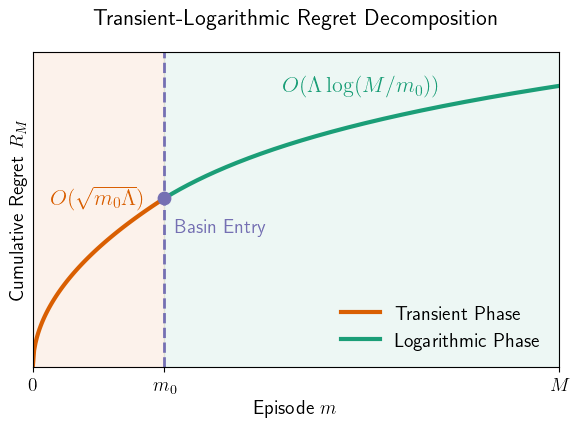

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.size": 14,
    "axes.spines.top": True,
    "axes.spines.right": True,
    "axes.labelsize": 14,
    "axes.titlesize": 16,
    "text.usetex": True,
})


# Define episode axes
M = 100
m0 = 25 # The basin entry point
m_transient = np.linspace(0, m0, 100)
m_log = np.linspace(m0, M, 300)

# Simulate Regret Curves mathematically
# 1. Transient phase: O(sqrt(m))
c1 = 5
regret_transient = c1 * np.sqrt(m_transient)

# 2. Logarithmic phase: O(log(m))
# Ensure the curve starts exactly where the transient phase ends
regret_m0 = c1 * np.sqrt(m0)
c2 = 12 # Scaling factor to make the log curve visually distinct
regret_log = regret_m0 + c2 * np.log(m_log / m0)

fig, ax = plt.subplots(figsize=(6,4.5))

# Plot the two distinct phases
ax.plot(m_transient, regret_transient, color='#d95f02', linewidth=3, label='Transient Phase')
ax.plot(m_log, regret_log, color='#1b9e77', linewidth=3, label='Logarithmic Phase')

# Mark the Basin Entry point
ax.axvline(x=m0, color='#7570b3', linestyle='--', linewidth=2)
ax.scatter([m0], [regret_m0], color='#7570b3', s=80, zorder=5)

# Annotate the Basin Entry
ax.annotate(r'Basin Entry', 
            xy=(m0, regret_m0), 
            xytext=(m0 + 2, regret_m0 - 5),
            color='#7570b3', 
            fontweight='bold')

# Shade the regions for visual separation
ax.axvspan(0, m0, color='#d95f02', alpha=0.08)
ax.axvspan(m0, M, color='#1b9e77', alpha=0.08)

# Add Big-O notation text directly onto the regions
ax.text(m0 / 2, regret_m0 * 1.0, 
        r'${O}(\sqrt{m_0 \Lambda})$', 
        fontsize=16, ha='center', va='center', color='#d95f02', fontweight='bold')

ax.text((M + m0) / 2, regret_m0 + c2 * np.log(M/(m0)), 
        r'${O}(\Lambda \log(M / m_0))$', 
        fontsize=16, ha='center', va='center', color='#1b9e77', fontweight='bold')

# Labels and Limits
ax.set_xlim(0, M)
ax.set_ylim(0, np.max(regret_log) + 5)
ax.set_xlabel('Episode $m$')
ax.set_ylabel('Cumulative Regret $R_M$')
ax.set_title('Transient-Logarithmic Regret Decomposition', pad=20)

# Clean up axes ticks for a more abstract, theoretical look
ax.set_xticks([0, m0, M])
ax.set_xticklabels(['$0$', '$m_0$', '$M$'])
ax.set_yticks([]) # Hide y-ticks to focus on the shape of the curve

plt.legend(loc='lower right', frameon=False)
plt.tight_layout()

# Save the figure with high DPI
plt.savefig('regret_decomposition.png', dpi=300, bbox_inches='tight')
plt.savefig('regret_decomposition.pdf', dpi=300, bbox_inches='tight')
plt.show()